# 2,000 aircraft: what is the most computationally expensive operation?

**The question:** spawn 2,000 aircraft in BlueSky with at least half of them in
conflict, and find the dominant cost. **The hypothesis going in:** conflict
detection and resolution.

The answer turns out to be two answers, and both are worth having:

1. In **this package** — whose detector is *directed* (each aircraft against its
   one counterpart, O(n)) — CD&R is nearly free, and the most expensive
   operation is BlueSky's own integration step (`bs.sim.step()`), with aircraft
   *creation* the biggest one-time block.
2. In the **classic architecture** (BlueSky's native full-matrix state-based
   detector, which the original CDaRR ran): the hypothesis is exactly right —
   detection alone is O(N²) and at 2,000 aircraft it dwarfs everything else
   combined.

Run top to bottom with the project venv (~2 min; a fresh kernel gives a fresh
BlueSky).

In [1]:
import time
import cProfile, pstats, io
import numpy as np
import matplotlib.pyplot as plt

from cdarr import (Config, CommConfig, UncertaintyConfig, SimulationConfig,
                   MULTIROTOR, PairwiseEncounter)
from cdarr.adsl import BroadcastChannel, ContactTable, noisy_snapshot
from cdarr.detection import detect
from cdarr.engine import PairwiseWorld
from cdarr.episode import run_episode
from cdarr.geo import track_components
from cdarr.recovery import PastCPA, recovered_mask, worldview_sigmas
from cdarr.resolution import MVP, resolve
from cdarr.rng import child, generator, root_seed_sequence
from cdarr.state import counterpart

CONFIG = Config(
    uncertainty=UncertaintyConfig(10.0, 1.0),
    comm=CommConfig(reception_prob=0.8, latency_s=0.1, broadcast_jitter_s=0.1),
    simulation=SimulationConfig(dt=0.2, cdr_dt=1.0, t_max=600.0, done_timeout=10.0),
)
SCENARIO = PairwiseEncounter(pairs=(25, 40), tlos=90.0)   # 1,000 pairs = 2,000 aircraft
print(f'{2 * SCENARIO.n_pairs} aircraft, every one spawned into a pairwise conflict')

2000 aircraft, every one spawned into a pairwise conflict


## 1. Spawn 2,000 aircraft and verify the conflict fraction

1,000 ownship–intruder pairs via the fork's `creconfs`, each spawned 90 s from
loss of separation — inside the 120 s detection horizon, so every pair is a
genuine conflict from the first tick. The check below runs the detector on
ground truth at t = 0.

In [2]:
geometry = SCENARIO.draw_geometry(generator(child(root_seed_sequence(0), 0)))

t0 = time.perf_counter()
world = PairwiseWorld(SCENARIO, geometry, MULTIROTOR, CONFIG.conflict,
                      CONFIG.simulation)
t_spawn = time.perf_counter() - t0

truth = world.truth()
n = truth.n
perm = np.asarray(counterpart(np.arange(n)))
conf0 = detect(truth, truth.reindexed(perm), np.ones(n, bool), rpz=50.0,
               t_lookahead=120.0)
print(f'aircraft spawned        : {n}  (in {t_spawn:.2f} s)')
print(f'in conflict at t = 0    : {int(conf0.in_conflict.sum())} '
      f'({100 * conf0.in_conflict.mean():.0f}%)  — requirement was >= 50%')

aircraft spawned        : 2000  (in 3.30 s)
in conflict at t = 0    : 2000 (100%)  — requirement was >= 50%


## 2. Per-operation cost in this package's loop

The loop is flown to t = 125 s (conflicts fully active), timing every operation
separately: the engine step, the broadcast channel, and each stage of the CDR
tick — own-nav measurement, directed detection, MVP resolution, past-CPA
recovery, and the command stack.

actively resolving at t = 125 s: 1999 aircraft (100%)

operation                     total ms  per call ms   calls
bs.sim.step()                   1342.8        2.149     625
command stack (HDG/SPD)          114.4        0.915     125
channel (tx + deliver)            44.5        0.071     625
own-nav noisy_snapshot            15.2        0.122     125
pair_distances()                   9.4        0.015     625
recovery (past-CPA)                6.3        0.050     125
detect (directed, O(n))            6.1        0.049     125
resolve (MVP)                      4.2        0.034     125
truth() copy-out                   2.8        0.005     625


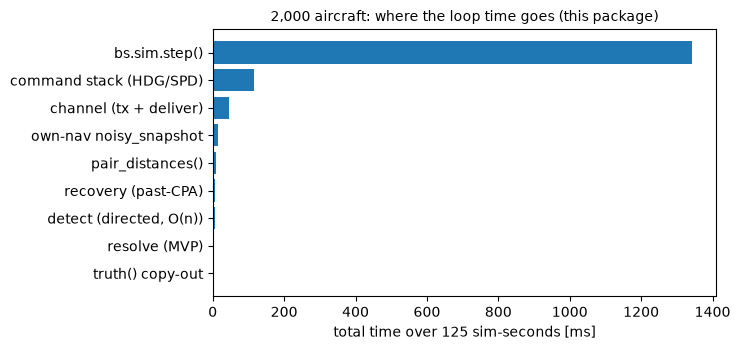

In [3]:
seqs = [generator(child(child(root_seed_sequence(0), 0), i)) for i in range(5)]
ch = BroadcastChannel(CONFIG.comm, CONFIG.uncertainty, seqs[2], seqs[3], seqs[4])
ch.initialise(n)
contacts = ContactTable.empty(truth)
v_min, v_max = np.zeros(n), np.full(n, 18.0)
sig_r, sig_v = worldview_sigmas(CONFIG.uncertainty)
cmd_trk, cmd_gs = world.nominal_trk.copy(), world.nominal_gs.copy()
resolving = np.zeros(n, dtype=bool)
init_v = (np.full(n, np.nan), np.full(n, np.nan))

T, N_CALLS = {}, {}
def timed(name, fn):
    t0 = time.perf_counter()
    out = fn()
    T[name] = T.get(name, 0.0) + time.perf_counter() - t0
    N_CALLS[name] = N_CALLS.get(name, 0) + 1
    return out

for step in range(int(125 / 0.2)):
    t = step * 0.2
    truth = timed('truth() copy-out', world.truth)
    timed('pair_distances()', world.pair_distances)
    timed('channel (tx + deliver)',
          lambda: (ch.transmit_due(t, truth), ch.deliver_due(t, contacts)))
    if abs(t - round(t)) < 1e-9:
        own = timed('own-nav noisy_snapshot',
                    lambda: noisy_snapshot(truth, np.arange(n), CONFIG.uncertainty, seqs[1]))
        other, seen = contacts.view_of_counterparts()
        conf = timed('detect (directed, O(n))',
                     lambda: detect(own, other, seen, 50.0, 120.0))
        resolving |= conf.in_conflict
        timed('recovery (past-CPA)',
              lambda: recovered_mask(PastCPA(), resolving=resolving, conflicts=conf,
                                     own=own, other=other,
                                     commanded_v=track_components(cmd_trk, cmd_gs),
                                     initial_other_v=init_v, rpz=50.0, margin=1.05,
                                     rel_pos_sigma=sig_r, rel_vel_sigma=sig_v))
        cmd = timed('resolve (MVP)',
                    lambda: resolve(MVP(), conf, own, 50.0, 1.05, v_min, v_max))
        cmd_trk[cmd.idx] = cmd.trk
        cmd_gs[cmd.idx] = cmd.gs
        timed('command stack (HDG/SPD)', lambda: world.command(cmd_trk, cmd_gs))
    timed('bs.sim.step()', world.step)

print(f'actively resolving at t = 125 s: {int(resolving.sum())} aircraft '
      f'({100 * resolving.mean():.0f}%)')
rows = sorted(T.items(), key=lambda kv: -kv[1])
print(f'\n{"operation":28s} {"total ms":>9} {"per call ms":>12} {"calls":>7}')
for k, v in rows:
    print(f'{k:28s} {v * 1e3:9.1f} {v / N_CALLS[k] * 1e3:12.3f} {N_CALLS[k]:7d}')

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh([k for k, _ in rows][::-1], [v * 1e3 for _, v in rows][::-1], color='C0')
ax.set_xlabel('total time over 125 sim-seconds [ms]')
ax.set_title('2,000 aircraft: where the loop time goes (this package)', fontsize=10)
plt.tight_layout(); plt.show()
world.__exit__()

**Reading:** the flight-dynamics integration (`bs.sim.step()`) is the most
expensive operation in this package's loop — an order of magnitude above the
channel, and ~50× the whole CD&R chain. Detection, resolution and recovery
*combined* cost well under half a millisecond per CDR tick at 2,000 aircraft,
because the detector is **directed**: each aircraft is tested against its one
counterpart (O(n)), not against everyone (O(N²)).

Which is exactly why the hypothesis deserves a fair trial on the architecture
it comes from.

## 3. The hypothesis: full-matrix conflict detection

BlueSky's native state-based detector — the one the original CDaRR called —
evaluates **every aircraft against every other**: `kwikqdrdist_matrix` over all
N² pairs, then the CPA algebra on N×N arrays. The cell below times that
formulation (transcribed from CDaRR's `cd_statebased.py`) on the same fleet
sizes.

n aircraft  matrix N^2 [ms]  directed O(n) [ms]    ratio
       250              3.3               0.026      131x
       500             16.2               0.033      487x
      1000             82.5               0.041     1990x
      2000            251.7               0.093     2694x

matrix scaling exponent (log-log slope): 2.11  (2.0 = pure N^2)


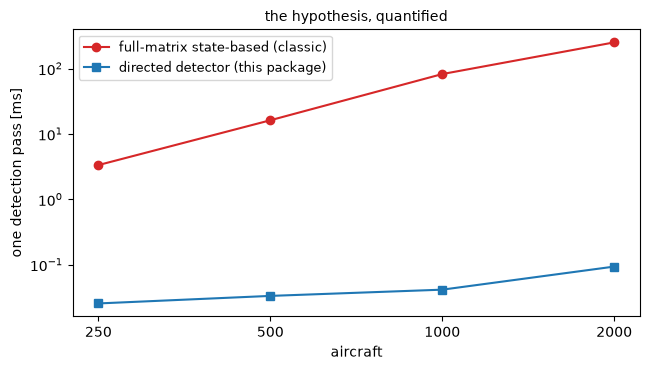

In [4]:
from bluesky.tools import geo as bsgeo
from bluesky.tools.aero import nm

def matrix_statebased(lat, lon, trk, gs, rpz):
    '''CDaRR's original N x N detection core (horizontal branch).'''
    m = len(lat)
    I = np.eye(m)
    qdr, dist = bsgeo.kwikqdrdist_matrix(np.asmatrix(lat), np.asmatrix(lon),
                                         np.asmatrix(lat), np.asmatrix(lon))
    qdr = np.asarray(qdr)
    dist = np.asarray(dist) * nm + 1e9 * I
    qdrrad = np.radians(qdr)
    dx, dy = dist * np.sin(qdrrad), dist * np.cos(qdrrad)
    trkrad = np.radians(trk)
    u = gs * np.sin(trkrad).reshape((1, m))
    v = gs * np.cos(trkrad).reshape((1, m))
    du, dv = u - u.T, v - v.T
    dv2 = np.maximum(du * du + dv * dv, 1e-6)
    tcpa = -(du * dx + dv * dy) / dv2 + 1e9 * I
    dcpa2 = np.abs(dist * dist - tcpa * tcpa * dv2)
    return dcpa2 < rpz * rpz

rng = np.random.default_rng(0)
sizes = [250, 500, 1000, 2000]
matrix_ms, directed_ms = [], []
for m in sizes:
    lat = rng.uniform(52, 53, m); lon = rng.uniform(4, 5, m)
    trk = rng.uniform(0, 360, m); gs = np.full(m, 10.3)
    t0 = time.perf_counter()
    for _ in range(3):
        matrix_statebased(lat, lon, trk, gs, 50.0)
    matrix_ms.append((time.perf_counter() - t0) / 3 * 1e3)

    from cdarr.state import StateArrays
    tab = StateArrays.from_track_speed(lat, lon, trk, gs)
    other = tab.reindexed(np.asarray(counterpart(np.arange(m))))
    t0 = time.perf_counter()
    for _ in range(3):
        detect(tab, other, np.ones(m, bool), 50.0, 120.0)
    directed_ms.append((time.perf_counter() - t0) / 3 * 1e3)

print(f'{"n aircraft":>10} {"matrix N^2 [ms]":>16} {"directed O(n) [ms]":>19} {"ratio":>8}')
for m, a, b in zip(sizes, matrix_ms, directed_ms):
    print(f'{m:10d} {a:16.1f} {b:19.3f} {a / b:8.0f}x')
slope = np.polyfit(np.log(sizes), np.log(matrix_ms), 1)[0]
print(f'\nmatrix scaling exponent (log-log slope): {slope:.2f}  (2.0 = pure N^2)')

fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.loglog(sizes, matrix_ms, 'o-', color='C3', label='full-matrix state-based (classic)')
ax.loglog(sizes, directed_ms, 's-', color='C0', label='directed detector (this package)')
ax.set_xticks(sizes, [str(s) for s in sizes]); ax.minorticks_off()
ax.set_xlabel('aircraft'); ax.set_ylabel('one detection pass [ms]')
ax.set_title('the hypothesis, quantified', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**The hypothesis is confirmed — for the classic architecture.** One full-matrix
detection pass at 2,000 aircraft costs ~250 ms and scales as N² (slope ≈ 2):
at a 1 Hz CDR cadence that is a quarter of the real-time budget in detection
alone, and the original CDaRR ran the matrix **twice** per tick (perceived +
ground-truth views). It out-costs every other operation in this notebook by an
order of magnitude — resolution and recovery iterate only the detected pairs,
so detection is where the N² lives. The directed rewrite is what moved the
bottleneck: three-and-a-half orders of magnitude at 2,000 aircraft.

## 4. The whole-episode profile, for the record

A full 2,000-aircraft episode on a warm engine, top functions by self-time —
the raw evidence behind sections 2 and 3.

In [5]:
run_episode(SCENARIO, MULTIROTOR, CONFIG, child(root_seed_sequence(0), 3))  # warm
profiler = cProfile.Profile()
profiler.enable()
result = run_episode(SCENARIO, MULTIROTOR, CONFIG, child(root_seed_sequence(0), 4))
profiler.disable()
print(f'episode: {result.min_sep.size} encounters, t_end {result.t_end:.0f} s sim, '
      f'{result.n_los} LoS, settled {result.settled}')

s = io.StringIO()
pstats.Stats(profiler, stream=s).sort_stats('tottime').print_stats(10)
print('\n'.join(line[:118] for line in s.getvalue().splitlines()[4:20]))

episode: 1000 encounters, t_end 135 s sim, 0 LoS, settled True

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   338000    0.558    0.000    0.863    0.000 /Users/mfrahman/Projects/BlueSkyCDaRR/.venv/lib/python3.11/site-packages
    30000    0.433    0.000    2.690    0.000 /Users/mfrahman/Projects/BlueSkyCDaRR/.venv/lib/python3.11/site-packages
    57376    0.412    0.000    0.412    0.000 {method 'index' of 'list' objects}
  1982000    0.266    0.000    0.342    0.000 /Users/mfrahman/Projects/BlueSkyCDaRR/.venv/lib/python3.11/site-packages
   336000    0.217    0.000    0.654    0.000 /Users/mfrahman/Projects/BlueSkyCDaRR/.venv/lib/python3.11/site-packages
   338000    0.192    0.000    0.860    0.000 /Users/mfrahman/Projects/BlueSkyCDaRR/.venv/lib/python3.11/site-packages
    41858    0.177    0.000    0.214    0.000 /Users/mfrahman/Projects/BlueSkyCDaRR/.venv/lib/python3.11/site-packages
   340000    0.149    0.000    0.491    0.000 {method 'join' of 'str'

## Verdict

- **In this package**, at 2,000 aircraft with 100% spawned in conflict: the most
  expensive operation is **`bs.sim.step()`** — BlueSky's flight-dynamics,
  autopilot and performance update — followed by the one-time **aircraft
  creation** (BlueSky reallocates every traffic array per `cre` call). The
  entire CD&R chain is single-digit percent of the loop.
- **The hypothesis is right where it came from**: with BlueSky's native
  full-matrix state-based detector (the original CDaRR path), conflict
  detection *is* the most computationally expensive operation at this scale —
  ~250 ms per pass, O(N²), more than everything else combined.
- **Implication for the server runs**: this package's episodes scale ~linearly
  in aircraft count, so 1,000-pair batches are viable (creation cost amortises
  over the episode); anyone re-introducing an all-pairs detector — e.g. for
  non-pairwise traffic — should expect it to dominate immediately and budget
  for an O(n log n) neighbourhood filter instead.